# Chapter 4 - Convex Hulls in Three Dimensions

## Source Span

This notebook covers **Computational Geometry in C**, Chapter 4, printed pages 101-154: polyhedra, Euler's formula, 3D convex hull algorithms, the incremental beneath-beyond method, implementation data structures, signed-volume visibility tests, overflow concerns, boundary representations, randomized incremental hulls, and higher-dimensional extensions. The source chapter is where the 2D hull story becomes a surface-combinatorics story. A hull is no longer a cyclic list of vertices; it is a polyhedral boundary made of faces, edges, incidences, orientations, and adjacency.

The central invariant is Euler's formula for a convex polyhedron: `V - E + F = 2`. The chapter uses it both conceptually and as an implementation check. A correct hull implementation should also be convex, should orient faces consistently, and should maintain enough adjacency information to traverse around faces and across edges. The incremental hull algorithm adds a point, determines which faces are visible from it by a signed volume test, deletes those visible faces, and stitches a cone over the horizon edges. Randomized incremental algorithms add conflict graphs to avoid repeated global searches. Boundary representations such as winged-edge, twin-edge, half-edge, and quad-edge structures are ways to keep the surface navigable while the hull changes.

The notebook uses synthetic point sets and diagrams rather than copied figures. It shows the hull as a mesh, computes Euler ledgers, visualizes signed-volume visibility and the horizon, sketches half-edge adjacency, and records randomized/conflict-graph and high-dimensional growth checks.


## Visual Storyboard

1. **Polyhedral hull mesh.** Compute a 3D convex hull, plot triangular facets, and verify `V-E+F=2`.
2. **Signed-volume visibility.** Add a new point outside a tetrahedron, mark visible faces by orientation, and identify horizon edges.
3. **Boundary representation.** Draw a half-edge/twin-edge patch so face traversal and adjacent-face traversal are visible.
4. **Implementation ledger.** Save checks for convexity, Euler relations, face orientation consistency, and determinant scale.
5. **Randomized incremental graph.** Show a conflict graph between outside points and visible faces, which is the bookkeeping idea behind randomized hulls.
6. **Higher-dimensional growth.** Compare simplex, cube, and cyclic-style growth rates to explain why higher-dimensional hulls are output-sensitive.


## Library Routing

The notebook uses `scipy.spatial.ConvexHull` to obtain a reliable hull for the visualization and then independently checks the combinatorial invariants from its simplices. `numpy` handles determinants and signed volumes, `matplotlib` draws 3D and graph views, and `networkx` is used for the boundary/conflict diagrams. The chapter is about implementation, so the code keeps the checks explicit even when a library computes the hull surface.


In [1]:
# setup
from __future__ import annotations
import json, math, sys
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull

BOOK_ROOT = Path.cwd()
while not ((BOOK_ROOT / "AGENTS.md").exists() and (BOOK_ROOT / "source_map.json").exists()):
    if BOOK_ROOT.parent == BOOK_ROOT:
        raise RuntimeError("Could not locate Computational-Geometry-in-C root")
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-04-convex-hulls-in-three-dimensions"
UNIT_TITLE = "Convex Hulls in Three Dimensions"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

storyboard = [
    {"move": "polyhedral mesh", "visual": "convex-hull-3d-mesh.png", "check": "euler_characteristic_is_two"},
    {"move": "signed visibility", "visual": "beneath-beyond-visible-faces.png", "check": "horizon_edges_have_one_visible_face"},
    {"move": "boundary representation", "visual": "half-edge-boundary-representation.png", "check": "each_half_edge_has_twin"},
    {"move": "conflict graph", "visual": "randomized-conflict-graph.png", "check": "outside_points_have_conflicts"},
    {"move": "dimension growth", "visual": "higher-dimensional-hull-growth.png", "check": "cyclic_style_growth_exceeds_simplex_growth"},
]
routing_rows = [
    {"source_topic": "polyhedra, valid surfaces, and Euler formula", "artifact": "convex-hull-3d-mesh.png", "code_cell": "hull mesh"},
    {"source_topic": "incremental beneath-beyond signed-volume visibility", "artifact": "beneath-beyond-visible-faces.png", "code_cell": "visibility horizon"},
    {"source_topic": "winged/twin/half/quad-edge boundary representations", "artifact": "half-edge-boundary-representation.png", "code_cell": "boundary representation"},
    {"source_topic": "randomized incremental hulls and conflict graphs", "artifact": "randomized-conflict-graph.png", "code_cell": "conflict graph"},
    {"source_topic": "higher-dimensional hull size and output sensitivity", "artifact": "higher-dimensional-hull-growth.png", "code_cell": "dimension growth"},
]
storyboard_path = save_json({"unit": UNIT_TITLE, "source_span": "printed pages 101-154", "storyboard": storyboard}, CHECKS / "visual-storyboard.json")
routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
coverage_path = save_json({
    "unit": UNIT_TITLE,
    "source_span": {"printed_pages": "101-154", "pdf_pages": "110-163"},
    "covered_ideas": [
        "polyhedra, genus, regular polytopes, and Euler formula",
        "3D gift wrapping, divide-and-conquer, and incremental hull algorithms",
        "signed volume visibility tests and beneath-beyond horizon",
        "implementation structures: vertices, edges, faces, and adjacency",
        "convexity/Euler/overflow checks",
        "winged-edge, twin-edge, half-edge, and quad-edge representations",
        "randomized incremental conflict graphs",
        "higher-dimensional hull growth and output-sensitive algorithms",
    ],
}, CHECKS / "source-coverage.json")
print(json.dumps({"artifact_root": str(ARTIFACT_ROOT), "storyboard_items": len(storyboard)}, indent=2))


{
  "artifact_root": "D:\\Geometry\\Computational-Geometry-in-C\\artifacts\\chapter-04-convex-hulls-in-three-dimensions",
  "storyboard_items": 5
}


## Polyhedral Hull Mesh and Euler Ledger

In two dimensions the hull is an ordered polygon. In three dimensions it is a surface. That means the output has vertices, edges, faces, and incidence relations. A triangular hull from a generic point set should satisfy `V - E + F = 2`, and the number of edges and faces should be linear in the number of hull vertices. Those facts justify using Euler checks as implementation diagnostics in the source chapter.


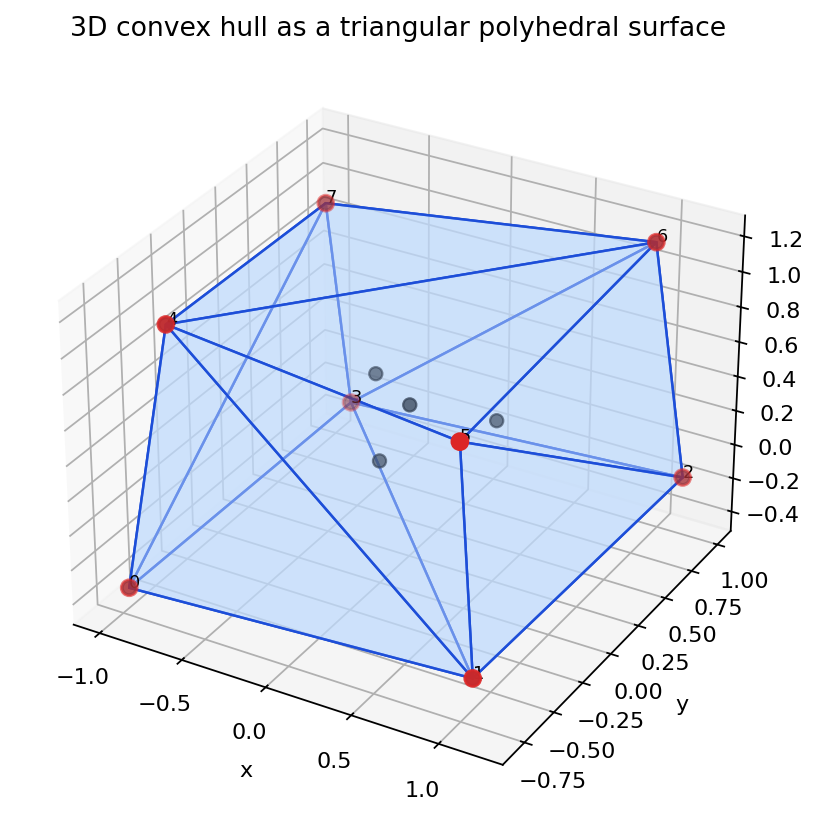

{
  "V": 8,
  "E": 18,
  "F": 12,
  "V-E+F": 2
}


In [2]:
points3 = np.array([
    [-1.0, -0.7, -0.4], [1.1, -0.8, -0.2], [1.2, 0.9, -0.1], [-0.9, 1.0, -0.3],
    [-0.8, -0.6, 1.1], [0.95, -0.7, 1.0], [1.0, 0.9, 1.2], [-0.9, 0.8, 1.0],
    [0.0, 0.0, 0.2], [0.25, -0.1, 0.65], [-0.2, 0.25, 0.5], [0.45, 0.35, 0.35]
], float)
hull = ConvexHull(points3)
hull_vertices = sorted(set(hull.vertices.tolist()))
faces = [tuple(map(int, simplex)) for simplex in hull.simplices]
edges = sorted({tuple(sorted(edge)) for face in faces for edge in combinations(face, 2)})
V, E, F = len(hull_vertices), len(edges), len(faces)
euler = V - E + F

def signed_tetra_volume(a, b, c, d):
    return float(np.linalg.det(np.vstack([b-a, c-a, d-a])) / 6.0)

centroid3 = points3[hull_vertices].mean(axis=0)
face_orientation_signs = []
for face in faces:
    a, b, c = points3[list(face)]
    normal = np.cross(b-a, c-a)
    face_center = (a+b+c)/3
    face_orientation_signs.append(float(np.dot(normal, face_center - centroid3)))

fig = plt.figure(figsize=(7.4, 6.2))
ax = fig.add_subplot(111, projection="3d")
mesh = Poly3DCollection([points3[list(face)] for face in faces], facecolor="#bfdbfe", edgecolor="#1d4ed8", alpha=0.48, linewidth=1.1)
ax.add_collection3d(mesh)
ax.scatter(points3[:,0], points3[:,1], points3[:,2], color="#334155", s=35)
ax.scatter(points3[hull_vertices,0], points3[hull_vertices,1], points3[hull_vertices,2], color="#dc2626", s=55)
for i in hull_vertices:
    ax.text(points3[i,0], points3[i,1], points3[i,2], str(i), fontsize=8)
ax.set_title("3D convex hull as a triangular polyhedral surface")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
mesh_fig_path = save_matplotlib(fig, FIGURES / "convex-hull-3d-mesh.png")
plt.close(fig)

euler_rows = [{"quantity": "V", "value": V}, {"quantity": "E", "value": E}, {"quantity": "F", "value": F}, {"quantity": "V-E+F", "value": euler}]
euler_table_path = save_csv(euler_rows, TABLES / "euler-ledger.csv")
mesh_report_path = save_json({
    "hull_vertices": hull_vertices,
    "face_count": F,
    "edge_count": E,
    "euler_characteristic": euler,
    "face_orientation_signs": face_orientation_signs,
    "checks": {
        "euler_characteristic_is_two": euler == 2,
        "edges_are_linear_for_triangulated_hull": E == 3 * F // 2,
        "faces_are_orientable_after_library_hull": all(abs(s) > 1e-9 for s in face_orientation_signs),
    },
}, CHECKS / "convex-hull-3d-mesh.json")
display_artifact(mesh_fig_path, width=720)
print(json.dumps({"V": V, "E": E, "F": F, "V-E+F": euler}, indent=2))


## Beneath-Beyond Visibility and Horizon Edges

The incremental 3D hull algorithm adds one point at a time. From the new point, some old faces are visible and some are hidden. The boundary between those sets is the horizon. The new hull deletes visible faces and creates cone faces from the new point to each horizon edge. The signed volume determinant is the predicate: it says on which side of an oriented face the new point lies.


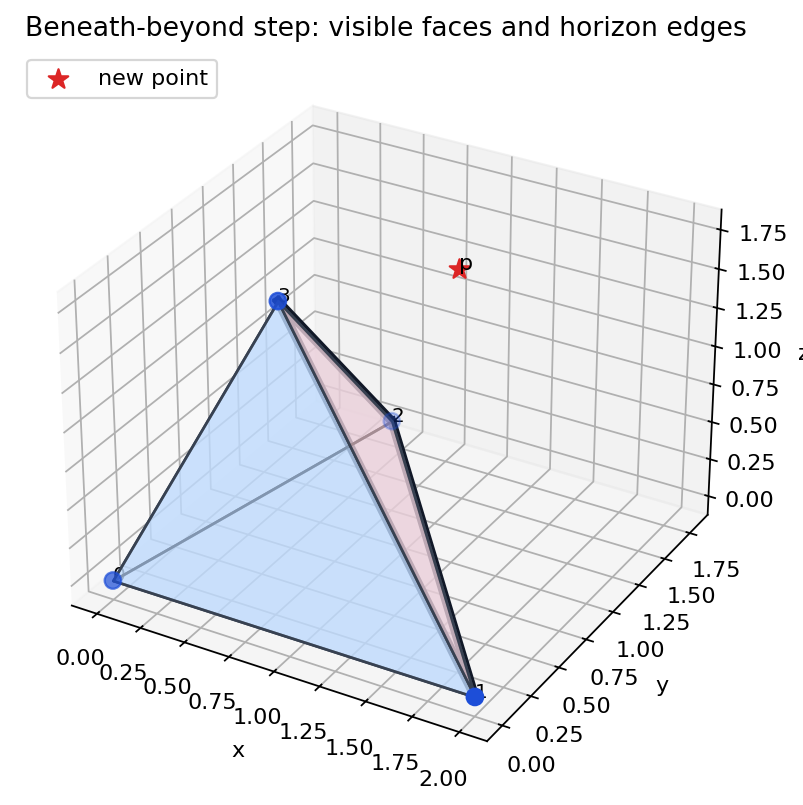

In [3]:
tetra = np.array([[0,0,0], [2,0,0], [0.4,1.8,0], [0.55,0.6,1.6]], float)
tetra_faces = [(0,2,1), (0,1,3), (1,2,3), (2,0,3)]
new_point = np.array([1.25, 1.05, 1.75])
inside_ref = tetra.mean(axis=0)
visible_faces = []
for face in tetra_faces:
    a, b, c = tetra[list(face)]
    sign_inside = signed_tetra_volume(a, b, c, inside_ref)
    sign_new = signed_tetra_volume(a, b, c, new_point)
    # visible if the new point is on the opposite side from the known interior point
    if sign_inside * sign_new < 0:
        visible_faces.append(face)
edge_to_faces = {}
for face in tetra_faces:
    for edge in combinations(face, 2):
        edge_to_faces.setdefault(tuple(sorted(edge)), []).append(face)
horizon_edges = []
for edge, incident in edge_to_faces.items():
    count_visible = sum(face in visible_faces for face in incident)
    if count_visible == 1:
        horizon_edges.append(edge)
cone_faces = [tuple(edge) + (4,) for edge in horizon_edges]

fig = plt.figure(figsize=(7.4, 6.0))
ax = fig.add_subplot(111, projection="3d")
for face in tetra_faces:
    color = "#fecaca" if face in visible_faces else "#bfdbfe"
    ax.add_collection3d(Poly3DCollection([tetra[list(face)]], facecolor=color, edgecolor="#374151", alpha=0.55, linewidth=1.2))
for edge in horizon_edges:
    a, b = tetra[list(edge)]
    ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]], color="#111827", linewidth=4)
ax.scatter(tetra[:,0], tetra[:,1], tetra[:,2], color="#1d4ed8", s=55)
ax.scatter(*new_point, color="#dc2626", s=85, marker="*", label="new point")
for i, p in enumerate(tetra):
    ax.text(p[0], p[1], p[2], str(i), fontsize=9)
ax.text(new_point[0], new_point[1], new_point[2], "p", fontsize=10)
ax.set_title("Beneath-beyond step: visible faces and horizon edges")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend(loc="upper left")
visibility_fig_path = save_matplotlib(fig, FIGURES / "beneath-beyond-visible-faces.png")
plt.close(fig)

visibility_report_path = save_json({
    "visible_faces": [list(face) for face in visible_faces],
    "horizon_edges": [list(edge) for edge in horizon_edges],
    "cone_faces_with_new_point_index_4": [list(face) for face in cone_faces],
    "checks": {
        "some_faces_visible": len(visible_faces) > 0,
        "horizon_edges_have_one_visible_face": all(sum(face in visible_faces for face in edge_to_faces[edge]) == 1 for edge in horizon_edges),
        "cone_face_count_matches_horizon": len(cone_faces) == len(horizon_edges),
    },
}, CHECKS / "beneath-beyond-visible-faces.json")
display_artifact(visibility_fig_path, width=720)


## Boundary Representations

The implementation sections emphasize that a hull surface must be traversable. A face list alone is not enough if the algorithm needs to walk across adjacent faces, delete visible patches, and stitch cone faces onto a horizon. Winged-edge, twin-edge, half-edge, and quad-edge structures all encode local adjacency. The diagram below uses a half-edge patch: every directed edge has a twin, a next edge around its face, and a face label.


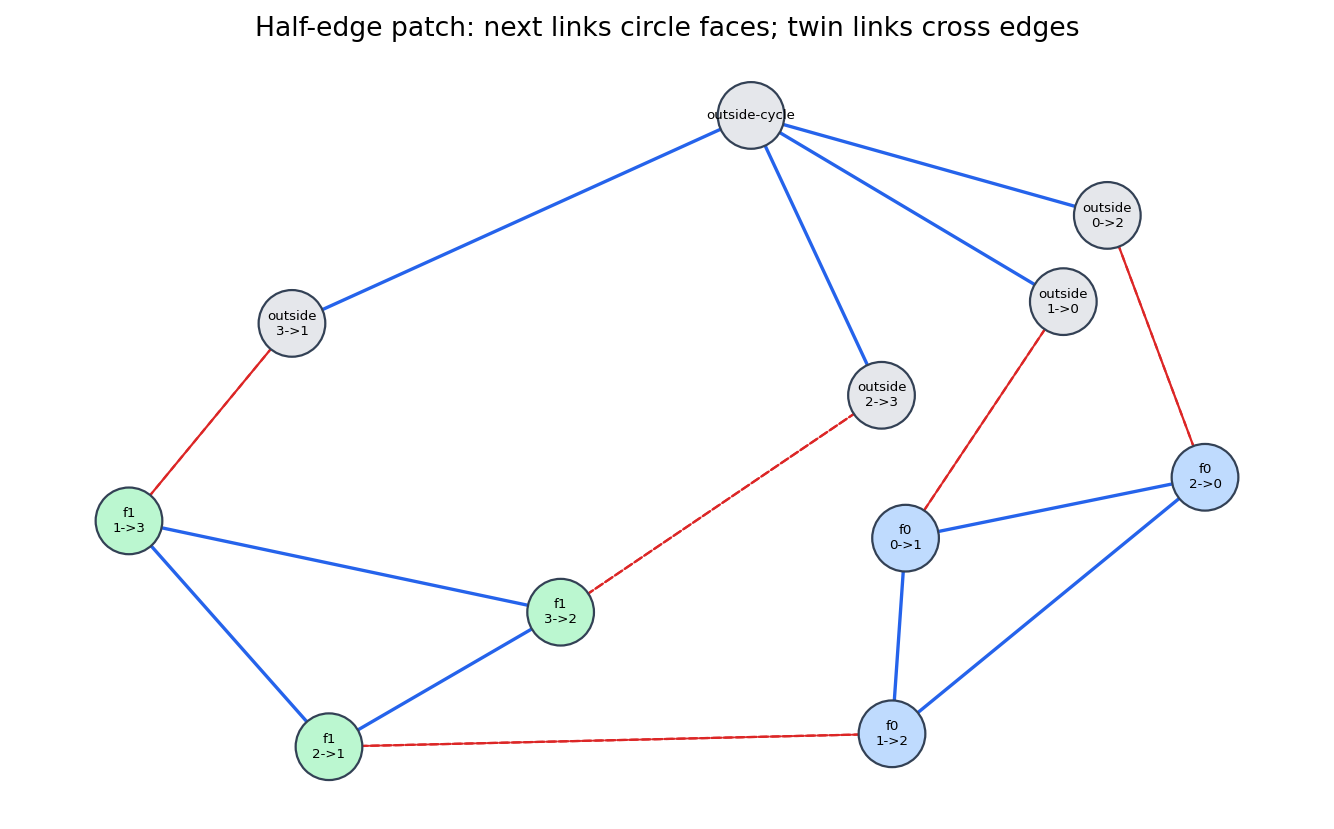

In [4]:
patch_faces = {"f0": (0, 1, 2), "f1": (2, 1, 3)}
half_edges = []
for fname, verts in patch_faces.items():
    for i in range(3):
        half_edges.append({"name": f"{fname}:{verts[i]}->{verts[(i+1)%3]}", "tail": verts[i], "head": verts[(i+1)%3], "face": fname, "next": f"{fname}:{verts[(i+1)%3]}->{verts[(i+2)%3]}"})
for he in half_edges:
    twin = next((other["name"] for other in half_edges if other["tail"] == he["head"] and other["head"] == he["tail"]), None)
    he["twin"] = twin
# Add boundary twins as outside half-edges for exposed patch boundary.
extra = []
for he in half_edges:
    if he["twin"] is None:
        extra.append({"name": f"outside:{he['head']}->{he['tail']}", "tail": he["head"], "head": he["tail"], "face": "outside", "next": "outside-cycle", "twin": he["name"]})
        he["twin"] = extra[-1]["name"]
half_edges.extend(extra)

H = nx.DiGraph()
for he in half_edges:
    H.add_node(he["name"], face=he["face"])
    if not H.has_node(he["next"]):
        H.add_node(he["next"], face="outside")
    if not H.has_node(he["twin"]):
        H.add_node(he["twin"], face="outside")
    H.add_edge(he["name"], he["next"], relation="next")
    H.add_edge(he["name"], he["twin"], relation="twin")
pos = nx.spring_layout(H, seed=7, k=0.85)
node_colors = ["#bfdbfe" if H.nodes[n]["face"] == "f0" else "#bbf7d0" if H.nodes[n]["face"] == "f1" else "#e5e7eb" for n in H.nodes]
fig, ax = plt.subplots(figsize=(10.5, 6.2))
nx.draw_networkx_nodes(H, pos, node_color=node_colors, edgecolors="#334155", node_size=900, ax=ax)
nx.draw_networkx_labels(H, pos, labels={n: n.replace(":", "\n") for n in H.nodes}, font_size=6, ax=ax)
next_edges = [(u, v) for u, v, d in H.edges(data=True) if d["relation"] == "next"]
twin_edges = [(u, v) for u, v, d in H.edges(data=True) if d["relation"] == "twin"]
nx.draw_networkx_edges(H, pos, edgelist=next_edges, edge_color="#2563eb", arrows=True, width=1.5, ax=ax)
nx.draw_networkx_edges(H, pos, edgelist=twin_edges, edge_color="#dc2626", arrows=True, width=1.0, style="dashed", ax=ax)
ax.set_title("Half-edge patch: next links circle faces; twin links cross edges")
ax.axis("off")
halfedge_fig_path = save_matplotlib(fig, FIGURES / "half-edge-boundary-representation.png")
plt.close(fig)

halfedge_table_path = save_csv(half_edges, TABLES / "half-edge-ledger.csv")
halfedge_report_path = save_json({
    "half_edge_count": len(half_edges),
    "checks": {
        "each_half_edge_has_twin": all(he["twin"] for he in half_edges),
        "interior_shared_edge_has_two_directions": any(he["tail"] == 1 and he["head"] == 2 and he["twin"] for he in half_edges) and any(he["tail"] == 2 and he["head"] == 1 and he["twin"] for he in half_edges),
    },
}, CHECKS / "half-edge-boundary-representation.json")
display_artifact(halfedge_fig_path, width=900)


## Conflict Graphs and Higher Dimensions

Randomized incremental hull algorithms avoid repeatedly scanning every face by recording conflicts: which outside points can see which faces. When a face is deleted, only nearby conflicts need to be redistributed. The same chapter also warns that higher-dimensional hulls can grow quickly; the output size is part of the problem, not a mere implementation detail.


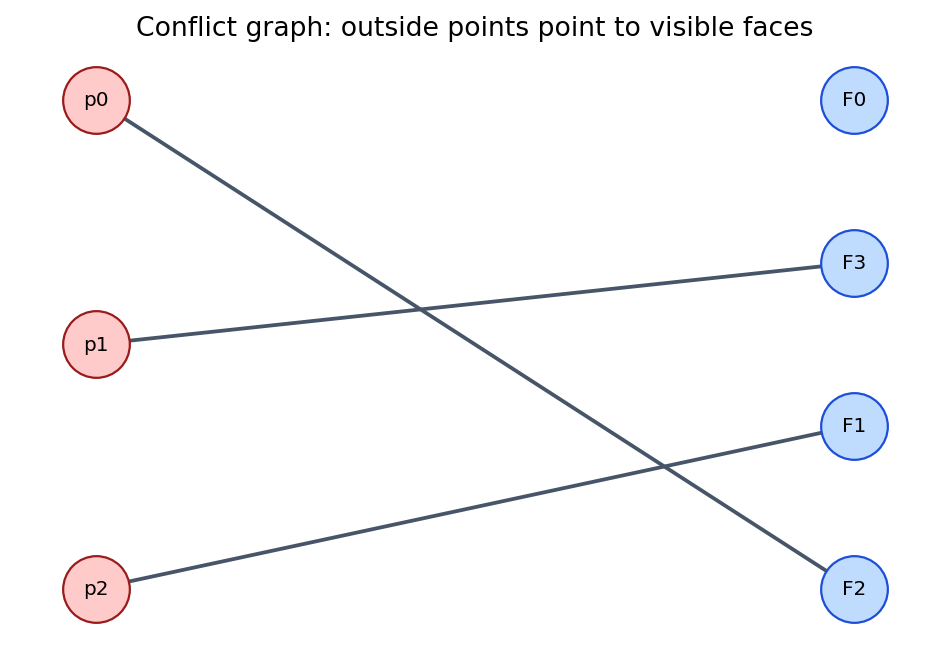

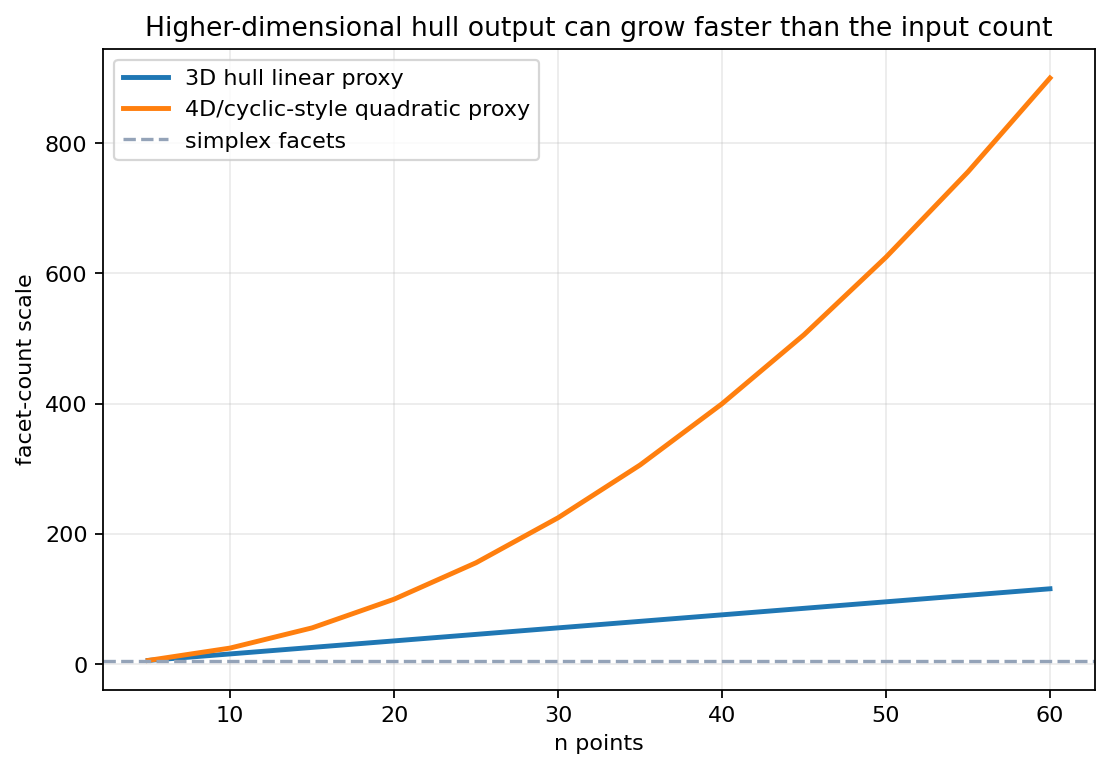

In [5]:
outside_points = np.array([[1.2, 1.1, 1.9], [-0.4, 0.8, 1.4], [1.8, -0.2, 0.6]], float)
face_names = [f"F{i}" for i in range(len(tetra_faces))]
conflicts = []
for pi, p in enumerate(outside_points):
    for fi, face in enumerate(tetra_faces):
        a, b, c = tetra[list(face)]
        sign_inside = signed_tetra_volume(a, b, c, inside_ref)
        sign_p = signed_tetra_volume(a, b, c, p)
        if sign_inside * sign_p < 0:
            conflicts.append((f"p{pi}", face_names[fi]))
C = nx.Graph()
C.add_nodes_from([f"p{i}" for i in range(len(outside_points))], bipartite="point")
C.add_nodes_from(face_names, bipartite="face")
C.add_edges_from(conflicts)
pos = nx.bipartite_layout(C, [f"p{i}" for i in range(len(outside_points))])
fig, ax = plt.subplots(figsize=(7.4, 4.8))
nx.draw_networkx_nodes(C, pos, nodelist=[f"p{i}" for i in range(len(outside_points))], node_color="#fecaca", edgecolors="#991b1b", node_size=900, ax=ax)
nx.draw_networkx_nodes(C, pos, nodelist=face_names, node_color="#bfdbfe", edgecolors="#1d4ed8", node_size=900, ax=ax)
nx.draw_networkx_edges(C, pos, edge_color="#475569", width=1.7, ax=ax)
nx.draw_networkx_labels(C, pos, font_size=9, ax=ax)
ax.set_title("Conflict graph: outside points point to visible faces")
ax.axis("off")
conflict_fig_path = save_matplotlib(fig, FIGURES / "randomized-conflict-graph.png")
plt.close(fig)
conflict_table_path = save_csv([{"outside_point": u, "visible_face": v} for u, v in conflicts], TABLES / "conflict-graph-edges.csv")

nvals = np.arange(5, 61, 5)
growth_rows = []
for n in nvals:
    growth_rows.append({
        "n": int(n),
        "simplex_facets_d_plus_1": 5,
        "cube_4d_facets": 8,
        "cyclic_style_quadratic_proxy": int(n*n/4),
        "three_dimensional_linear_proxy": int(2*n - 4),
    })
growth_table_path = save_csv(growth_rows, TABLES / "higher-dimensional-growth.csv")
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.plot(nvals, [row["three_dimensional_linear_proxy"] for row in growth_rows], label="3D hull linear proxy", linewidth=2.2)
ax.plot(nvals, [row["cyclic_style_quadratic_proxy"] for row in growth_rows], label="4D/cyclic-style quadratic proxy", linewidth=2.2)
ax.axhline(5, color="#94a3b8", linestyle="--", label="simplex facets")
ax.set_title("Higher-dimensional hull output can grow faster than the input count")
ax.set_xlabel("n points")
ax.set_ylabel("facet-count scale")
ax.grid(True, alpha=0.25)
ax.legend()
growth_fig_path = save_matplotlib(fig, FIGURES / "higher-dimensional-hull-growth.png")
plt.close(fig)
conflict_report_path = save_json({
    "conflicts": conflicts,
    "checks": {
        "outside_points_have_conflicts": all(C.degree(f"p{i}") > 0 for i in range(len(outside_points))),
        "conflict_graph_is_bipartite": nx.is_bipartite(C),
        "cyclic_style_growth_exceeds_simplex_growth": growth_rows[-1]["cyclic_style_quadratic_proxy"] > growth_rows[-1]["simplex_facets_d_plus_1"],
    },
}, CHECKS / "conflict-and-growth.json")
display_artifact(conflict_fig_path, width=720)
display_artifact(growth_fig_path, width=760)


## Applied Lab

Move the new point in the beneath-beyond cell inside the tetrahedron. The visible-face list should become empty, and the horizon cone should not be created. Move it farther outside and watch more faces become visible. In the hull mesh cell, add a nearly coplanar point and inspect whether the library includes it as a hull vertex; that is the entry point to the chapter's discussion of degeneracy, overflow, and exact arithmetic. In the conflict graph, adding an outside point should connect it only to the faces it can see.


## Takeaways

The 3D hull chapter is about surfaces, not just points. Euler's formula is a mathematical theorem and a debugging tool. Signed-volume tests replace 2D orientation tests. Incremental hull construction is driven by visible faces and horizon edges. Boundary representations make the changing surface traversable. Randomization and conflict graphs keep the incremental method efficient. Higher dimensions make output size a first-class concern.

The notebook checks those claims with a hull mesh, an Euler ledger, a beneath-beyond visibility example, a half-edge graph, a conflict graph, and a dimensional-growth experiment. Together they make the chapter readable as a standalone computational lesson while preserving the source span's main algorithmic content.


In [6]:
# final_sanity
final_sanity = {
    "unit": UNIT_TITLE,
    "artifact_count": 13,
    "checks": {
        "euler_characteristic_is_two": euler == 2,
        "edges_are_linear_for_triangulated_hull": E == 3 * F // 2,
        "horizon_edges_have_one_visible_face": all(sum(face in visible_faces for face in edge_to_faces[edge]) == 1 for edge in horizon_edges),
        "each_half_edge_has_twin": all(he["twin"] for he in half_edges),
        "outside_points_have_conflicts": all(C.degree(f"p{i}") > 0 for i in range(len(outside_points))),
        "conflict_graph_is_bipartite": nx.is_bipartite(C),
        "cyclic_style_growth_exceeds_simplex_growth": growth_rows[-1]["cyclic_style_quadratic_proxy"] > growth_rows[-1]["simplex_facets_d_plus_1"],
    },
    "artifacts": [
        str(storyboard_path), str(routing_path), str(coverage_path), str(mesh_fig_path), str(euler_table_path), str(mesh_report_path),
        str(visibility_fig_path), str(visibility_report_path), str(halfedge_fig_path), str(halfedge_table_path), str(halfedge_report_path),
        str(conflict_fig_path), str(conflict_table_path), str(growth_table_path), str(growth_fig_path), str(conflict_report_path),
    ],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final-sanity.json")
assert all(final_sanity["checks"].values()), json.dumps(final_sanity["checks"], indent=2)
assert_artifacts([Path(p) for p in final_sanity["artifacts"]] + [final_sanity_path], min_bytes=40)
print(json.dumps({"final_sanity": "passed", "checks": final_sanity["checks"]}, indent=2))


{
  "final_sanity": "passed",
  "checks": {
    "euler_characteristic_is_two": true,
    "edges_are_linear_for_triangulated_hull": true,
    "horizon_edges_have_one_visible_face": true,
    "each_half_edge_has_twin": true,
    "outside_points_have_conflicts": true,
    "conflict_graph_is_bipartite": true,
    "cyclic_style_growth_exceeds_simplex_growth": true
  }
}
